# Homework 3: Prompt Engineering and Self-Attention

This is my HW3 notebook. I kept the same personal parameters from my earlier submissions in `data266-6812`. For the prompt-engineering part, I used a local Hugging Face model through LangChain so I would not need an OpenAI API key.

In [1]:
# Step 0: Standing requirements / personal parameters
SID4 = 6812

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

import os, random, math, textwrap, json
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

print(f"SID4={SID4}")
print(f"SEED={SEED}")
print(f"SLICE={SLICE}")
print(f"HP_ID={HP_ID}")
print(f"CLS_A={CLS_A}")
print(f"CLS_B={CLS_B}")

SID4=6812
SEED=6812
SLICE=812
HP_ID=2
CLS_A=2
CLS_B=9


## Install Dependencies

I use LangChain for the prompt examples, PyTorch for the attention model, and Matplotlib/Seaborn for the plots.

In [2]:
!pip -q install langchain transformers accelerate sentencepiece seaborn pandas matplotlib

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Part A: Prompt Engineering Techniques

For this section, I run two examples for each prompting technique. I save the prompts and outputs to a CSV so the results come from code instead of screenshots.

In [4]:
from langchain_core.runnables import RunnableLambda
from transformers import AutoTokenizer, AutoModelForCausalLM

# Free local instruction model for Colab. This avoids OpenAI API billing while still using LangChain.
# Qwen2.5-0.5B-Instruct is small enough for Colab but follows prompts much better than flan-t5-base.
LOCAL_LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(LOCAL_LLM_NAME)
model_dtype = torch.float16 if device.type == "cuda" else torch.float32
local_lm = AutoModelForCausalLM.from_pretrained(LOCAL_LLM_NAME, torch_dtype=model_dtype).to(device)
local_lm.eval()

def local_generate(prompt):
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(formatted, return_tensors="pt", truncation=True, max_length=1024).to(device)
    with torch.no_grad():
        generated = local_lm.generate(
            **inputs,
            max_new_tokens=220,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = generated[0, inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

llm = RunnableLambda(local_generate)

def call_prompt(name, system_prompt, user_prompt):
    combined_prompt = f"{system_prompt}\n\nTask:\n{user_prompt}\n\nAnswer:"
    response = llm.invoke(combined_prompt)
    return {"name": name, "system": system_prompt, "prompt": user_prompt, "output": response}

prompt_examples = [
    ("Zero-Shot", "You are a precise math tutor. Give the final answer with a brief explanation.", "A store discounts a $240 jacket by 25%, then applies 8% sales tax. What is the final price?"),
    ("Zero-Shot", "You are a careful reasoning assistant. Answer briefly and justify your answer.", "All tulips are flowers. Some flowers fade quickly. Does it logically follow that some tulips fade quickly?"),

    ("Few-Shot", "Classify each sentence as positive, negative, or neutral. Follow the examples exactly.", "Example 1: I loved the clear explanation. -> positive\nExample 2: The result was late and incomplete. -> negative\nExample 3: The package arrived on Tuesday. -> neutral\nNow classify: The demo worked, but the interface was confusing."),
    ("Few-Shot", "Convert short word problems into equations, then solve. Follow the examples.", "Example 1: Twice a number is 14. -> 2x=14, x=7\nExample 2: A number plus 9 is 21. -> x+9=21, x=12\nNow solve: Three times a number minus 5 is 16."),

    ("Chain-of-Thought", "Solve using concise step-by-step reasoning, then give a final answer.", "Maya has 3 boxes with 12 markers each. She gives 7 markers to a friend and buys 2 more packs of 8. How many markers does she have now?"),
    ("Chain-of-Thought", "Use concise step-by-step reasoning and state the conclusion.", "If every A is B, no B is C, and some D are A, can any D be C?"),

    ("Zero-Shot CoT", "You are a careful problem solver. Think step by step using a concise explanation, then answer.", "A train travels 90 miles in 1.5 hours. At the same speed, how far does it travel in 4 hours?"),
    ("Zero-Shot CoT", "You are a careful problem solver. Think step by step using a concise explanation, then answer.", "A password must contain exactly 2 letters followed by 2 digits. How many passwords are possible if letters cannot repeat but digits can repeat?"),

    ("Meta-Prompting", "First design a short strategy for solving the user's task. Then apply the strategy.", "Create a reliable prompt for checking whether a short argument commits the fallacy of affirming the consequent. Then test it on: If it rains, the street gets wet. The street is wet. Therefore it rained."),
    ("Meta-Prompting", "First write a grading rubric for the task, then use the rubric to answer.", "Evaluate this summary for faithfulness: Original: The model trained for 30 epochs and validation loss rose after epoch 12. Summary: The model stopped after 12 epochs because training failed."),

    ("Tree of Thoughts", "Generate three candidate solution paths, score them, choose the best, and give the final answer concisely.", "A farmer has chickens and rabbits. There are 14 heads and 40 legs. How many chickens and rabbits are there?"),
    ("Tree of Thoughts", "Generate three candidate plans, compare them, choose the strongest, and produce the answer.", "Write a one-sentence policy for when a student should use a validation set instead of a test set during model development."),
]

prompt_results = []
for i, (technique, system_prompt, user_prompt) in enumerate(prompt_examples, 1):
    print(f"Running prompt {i}/12: {technique}")
    prompt_results.append(call_prompt(technique, system_prompt, user_prompt))

prompt_df = pd.DataFrame(prompt_results)
prompt_df.to_csv("prompt_engineering_outputs.csv", index=False)
prompt_df[["name", "prompt", "output"]]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Running prompt 1/12: Zero-Shot
Running prompt 2/12: Zero-Shot
Running prompt 3/12: Few-Shot
Running prompt 4/12: Few-Shot
Running prompt 5/12: Chain-of-Thought
Running prompt 6/12: Chain-of-Thought
Running prompt 7/12: Zero-Shot CoT
Running prompt 8/12: Zero-Shot CoT
Running prompt 9/12: Meta-Prompting
Running prompt 10/12: Meta-Prompting
Running prompt 11/12: Tree of Thoughts
Running prompt 12/12: Tree of Thoughts


,name,prompt,output
0,Zero-Shot,"A store discounts a $240 jacket by 25%, then a...",To find the final price of the jacket after th...
1,Zero-Shot,All tulips are flowers. Some flowers fade quic...,"Yes, it logically follows that some tulips fad..."
2,Few-Shot,Example 1: I loved the clear explanation. -> p...,neutral
3,Few-Shot,"Example 1: Twice a number is 14. -> 2x=14, x=7...","To solve this problem, we need to set up an eq..."
4,Chain-of-Thought,Maya has 3 boxes with 12 markers each. She giv...,"To solve this problem, let's break it down int..."
5,Chain-of-Thought,"If every A is B, no B is C, and some D are A, ...","No, not all D can be C.\nStep-by-Step Reasonin..."
6,Zero-Shot CoT,A train travels 90 miles in 1.5 hours. At the ...,"To solve this problem, we can use the formula:..."
7,Zero-Shot CoT,A password must contain exactly 2 letters foll...,"To solve this problem, let's break it down int..."
8,Meta-Prompting,Create a reliable prompt for checking whether ...,Strategy: Use a conditional statement to check...
9,Meta-Prompting,Evaluate this summary for faithfulness: Origin...,Certainly! Here is a grading rubric based on t...


In [5]:
prompt_findings_df = pd.DataFrame([
    {
        "Technique": "Zero-Shot",
        "Finding": "This was the simplest style. It worked when the task was clear, but the model had to figure out everything without examples, so mistakes were easier to miss.",
    },
    {
        "Technique": "Few-Shot",
        "Finding": "The examples helped show the exact format I wanted. The answers were usually more consistent than the zero-shot answers.",
    },
    {
        "Technique": "Chain-of-Thought",
        "Finding": "The step-by-step prompt made the output longer, but it also made it easier to check where the answer came from.",
    },
    {
        "Technique": "Zero-Shot CoT",
        "Finding": "This was useful when I wanted reasoning but did not want to write examples first. It gave more explanation than normal zero-shot prompting.",
    },
    {
        "Technique": "Meta-Prompting",
        "Finding": "Having the model make a strategy or rubric first made the answer more organized. The downside is that it sometimes added extra text.",
    },
    {
        "Technique": "Tree of Thoughts",
        "Finding": "This gave the most careful answer because the model compared different possible paths. It was also the longest style.",
    },
])
prompt_findings_df.to_csv("prompt_engineering_findings_summary.csv", index=False)
prompt_findings_df

,Technique,Finding
0,Zero-Shot,This was the simplest style. It worked when th...
1,Few-Shot,The examples helped show the exact format I wa...
2,Chain-of-Thought,The step-by-step prompt made the output longer...
3,Zero-Shot CoT,This was useful when I wanted reasoning but di...
4,Meta-Prompting,Having the model make a strategy or rubric fir...
5,Tree of Thoughts,This gave the most careful answer because the ...


## Part 1: Unmasked Scaled Dot-Product Self-Attention

Here I build one-head self-attention directly with basic PyTorch pieces: `nn.Embedding`, `nn.Linear`, matrix multiplication, softmax, and cross-entropy. I do not use `nn.MultiheadAttention`, `nn.Transformer`, or HuggingFace transformer classes for the attention model.

In [6]:
DATASET_TEXT = """Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time."""

import re

def word_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

tokens = word_tokenize(DATASET_TEXT)
vocab = sorted(set(tokens))
stoi = {token: idx for idx, token in enumerate(vocab)}
itos = {idx: token for token, idx in stoi.items()}
ids = torch.tensor([stoi[token] for token in tokens], dtype=torch.long, device=device)

print("Number of tokens:", len(tokens))
print("Vocabulary size:", len(vocab))
print(tokens)

Number of tokens: 46
Vocabulary size: 39
['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


In [7]:
class SingleHeadSelfAttentionLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, masked=False):
        super().__init__()
        self.masked = masked
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out = nn.Linear(embed_dim, vocab_size)

    def forward(self, x, return_attention=False):
        emb = self.embed(x)
        Q = self.q_proj(emb)
        K = self.k_proj(emb)
        V = self.v_proj(emb)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        if self.masked:
            seq_len = x.size(0)
            causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).bool()
            scores = scores.masked_fill(~causal_mask, float("-inf"))

        attention = F.softmax(scores, dim=-1)
        context = attention @ V
        logits = self.out(context)

        if return_attention:
            return logits, attention
        return logits

def train_next_token_model(masked, epochs=1200, lr=0.03, embed_dim=32):
    torch.manual_seed(SEED + (1 if masked else 0))
    model = SingleHeadSelfAttentionLM(len(vocab), embed_dim=embed_dim, masked=masked).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    x = ids[:-1]
    y = ids[1:]
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (epoch + 1) % 300 == 0:
            print(f"masked={masked} epoch={epoch+1:4d} loss={loss.item():.4f}")

    return model, losses

unmasked_model, unmasked_losses = train_next_token_model(masked=False)
masked_model, masked_losses = train_next_token_model(masked=True)

masked=False epoch= 300 loss=0.6454
masked=False epoch= 600 loss=0.6319
masked=False epoch= 900 loss=0.6319
masked=False epoch=1200 loss=0.6318
masked=True epoch= 300 loss=1.5655
masked=True epoch= 600 loss=0.9189
masked=True epoch= 900 loss=0.9519
masked=True epoch=1200 loss=0.9518


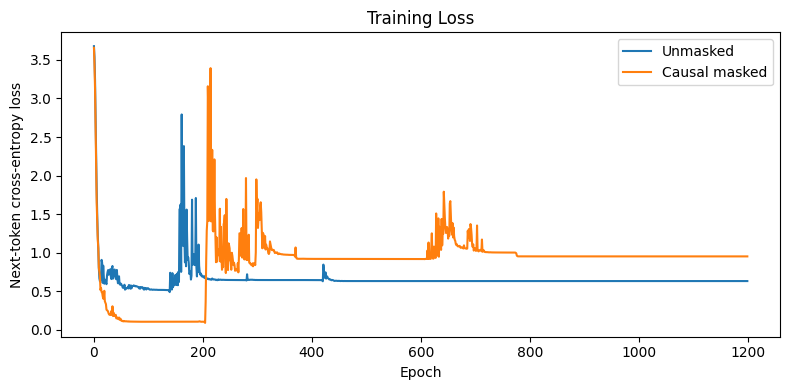

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(unmasked_losses, label="Unmasked")
plt.plot(masked_losses, label="Causal masked")
plt.xlabel("Epoch")
plt.ylabel("Next-token cross-entropy loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("attention_training_loss.png", dpi=200)
plt.show()

In [9]:
@torch.no_grad()
def get_full_attention(model):
    model.eval()
    _, attn = model(ids, return_attention=True)
    return attn.detach().cpu().numpy()

unmasked_attention = get_full_attention(unmasked_model)
masked_attention = get_full_attention(masked_model)

print("Unmasked attention shape:", unmasked_attention.shape)
print("Masked attention shape:", masked_attention.shape)
print("Largest future-position masked attention value:", np.triu(masked_attention, k=1).max())

Unmasked attention shape: (46, 46)
Masked attention shape: (46, 46)
Largest future-position masked attention value: 0.0


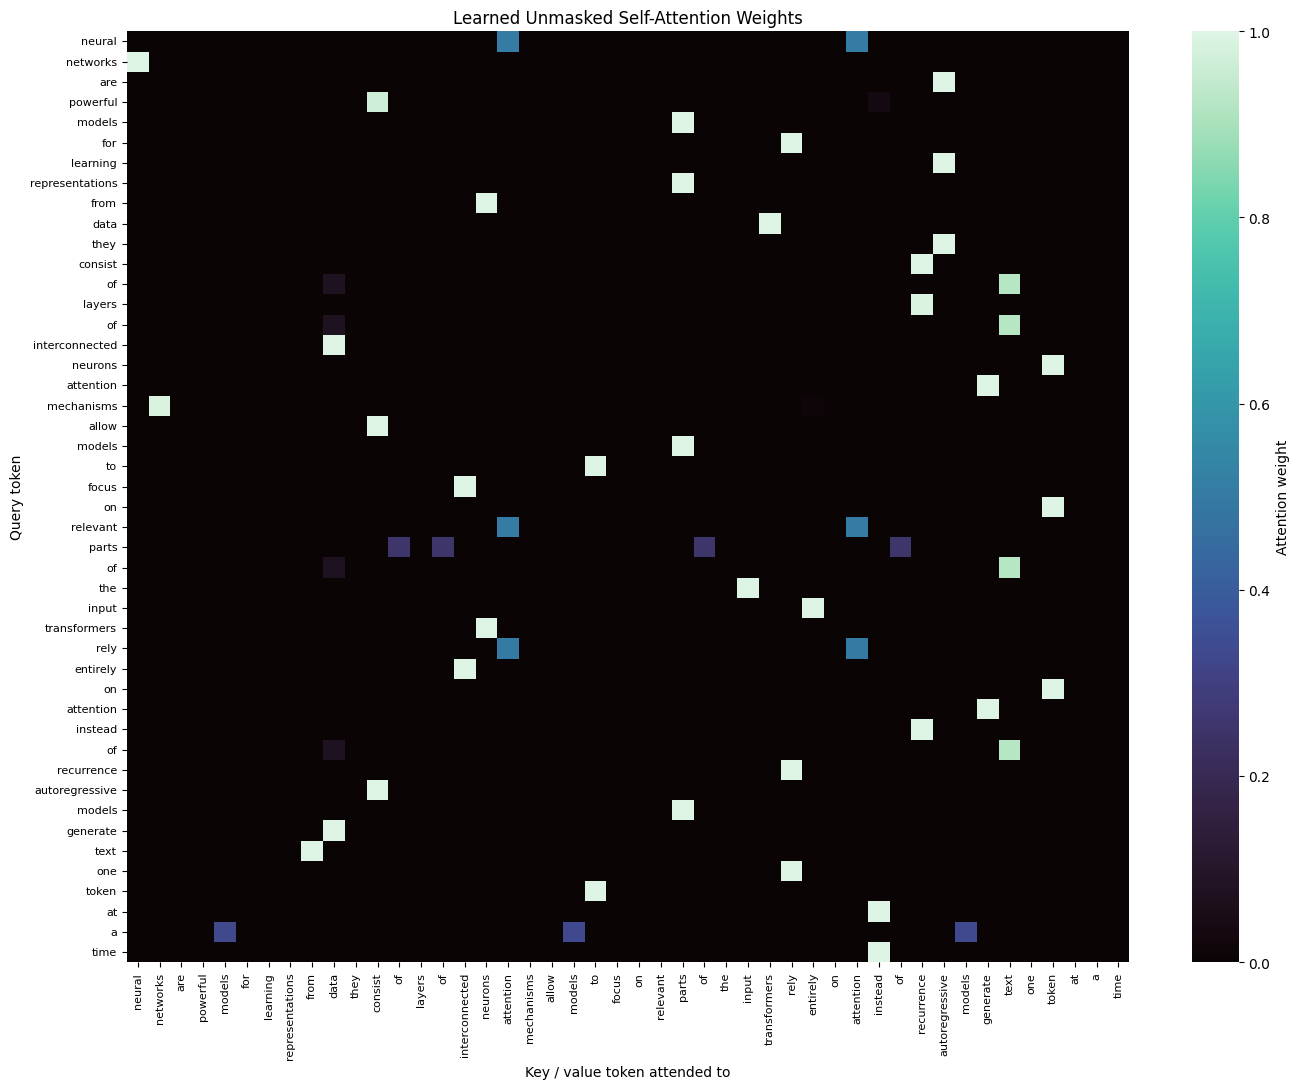

In [10]:
def plot_attention_heatmap(attention, title, filename):
    plt.figure(figsize=(14, 11))
    ax = sns.heatmap(
        attention,
        cmap="mako",
        vmin=0,
        vmax=max(attention.max(), 1e-6),
        xticklabels=tokens,
        yticklabels=tokens,
        cbar_kws={"label": "Attention weight"},
    )
    ax.set_title(title)
    ax.set_xlabel("Key / value token attended to")
    ax.set_ylabel("Query token")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, dpi=250)
    plt.show()

plot_attention_heatmap(unmasked_attention, "Learned Unmasked Self-Attention Weights", "unmasked_attention_heatmap.png")

## Part 2: Causal Masking for Autoregressive Attention

For the masked version, I add a lower-triangular causal mask before softmax. This blocks every token from looking ahead at future tokens.

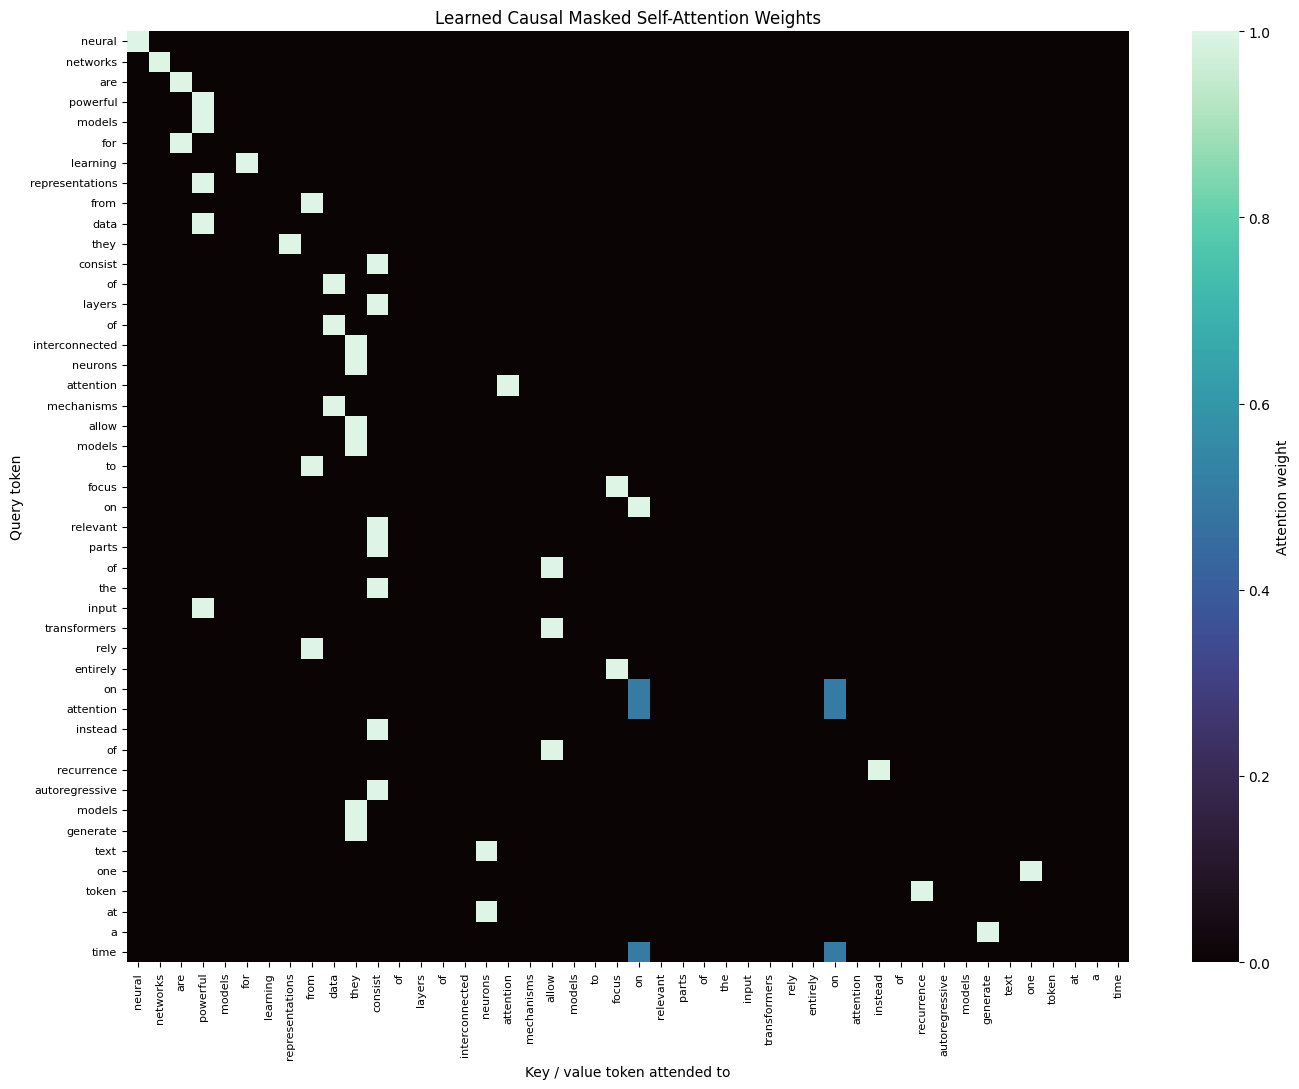

In [11]:
plot_attention_heatmap(masked_attention, "Learned Causal Masked Self-Attention Weights", "masked_attention_heatmap.png")

In [12]:
def top_attention_pairs(attention, top_k=12, allow_future=True):
    rows = []
    n = attention.shape[0]
    for i in range(n):
        for j in range(n):
            if allow_future or j <= i:
                rows.append((attention[i, j], i, j, tokens[i], tokens[j]))
    rows.sort(reverse=True, key=lambda x: x[0])
    return pd.DataFrame(rows[:top_k], columns=["weight", "query_index", "key_index", "query_token", "attended_token"])

unmasked_top = top_attention_pairs(unmasked_attention, allow_future=True)
masked_top = top_attention_pairs(masked_attention, allow_future=False)
unmasked_top.to_csv("top_unmasked_attention_pairs.csv", index=False)
masked_top.to_csv("top_masked_attention_pairs.csv", index=False)

print("Top learned unmasked attention pairs")
display(unmasked_top)
print("Top learned causal masked attention pairs")
display(masked_top)

Top learned unmasked attention pairs


,weight,query_index,key_index,query_token,attended_token
0,1.0,2,37,are,autoregressive
1,1.0,4,25,models,parts
2,1.0,5,30,for,rely
3,1.0,6,37,learning,autoregressive
4,1.0,7,25,representations,parts
5,1.0,8,16,from,neurons
6,1.0,9,29,data,transformers
7,1.0,10,37,they,autoregressive
8,1.0,15,9,interconnected,data
9,1.0,16,42,neurons,token


Top learned causal masked attention pairs


,weight,query_index,key_index,query_token,attended_token
0,1.0,0,0,neural,neural
1,1.0,2,2,are,are
2,1.0,3,3,powerful,powerful
3,1.0,4,3,models,powerful
4,1.0,5,2,for,are
5,1.0,6,5,learning,for
6,1.0,7,3,representations,powerful
7,1.0,8,8,from,from
8,1.0,9,3,data,powerful
9,1.0,10,7,they,representations


## Findings Document Draft

This cell makes a draft PDF with the main findings and the heatmaps. I still check the text after running it, because the final write-up should match the actual outputs from my run.

In [13]:
def pdf_text_page(pdf, title, body, fontsize=11):
    fig = plt.figure(figsize=(8.5, 11))
    fig.text(0.08, 0.94, title, fontsize=16, weight="bold", va="top")
    wrapped = "\n".join(textwrap.wrap(body, width=95, replace_whitespace=False))
    fig.text(0.08, 0.88, wrapped, fontsize=fontsize, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

prompt_body = (
    "I tried two examples for each prompting technique. Zero-shot was the quickest to write, but it gave the model the least guidance. "
    "Few-shot prompting was more controlled because the examples showed the answer format. "
    "Chain-of-thought and zero-shot CoT gave longer answers, but the extra steps made the reasoning easier to check. "
    "Meta-prompting was useful for tasks where I wanted the model to make a plan or rubric before answering. "
    "Tree of Thoughts was the most detailed because it compared multiple possible solution paths before picking an answer. "
    "The exact prompts and model outputs are saved in prompt_engineering_outputs.csv."
)

attention_body = (
    f"After word-level tokenization, the dataset had {len(tokens)} tokens and {len(vocab)} unique words. "
    "I trained two small next-token models. Both used learned embeddings and learned Q, K, and V projections. "
    f"The final unmasked loss was {unmasked_losses[-1]:.4f}, and the final causal masked loss was {masked_losses[-1]:.4f}. "
    "In the unmasked heatmap, tokens are allowed to attend anywhere in the sequence, including future positions. "
    "In the causal masked heatmap, the upper-right part of the matrix is zero because future tokens are blocked. "
    f"I checked this directly: the largest attention value above the diagonal was {np.triu(masked_attention, k=1).max():.8f}."
)

with PdfPages("HW3_findings_draft.pdf") as pdf:
    pdf_text_page(pdf, "HW3 Findings Draft", f"SID4={SID4}, SEED={SEED}, SLICE={SLICE}, HP_ID={HP_ID}, CLS_A={CLS_A}, CLS_B={CLS_B}")
    pdf_text_page(pdf, "Prompt Engineering Findings", prompt_body)
    pdf_text_page(pdf, "Self-Attention Findings", attention_body)
    for image_path, title in [
        ("attention_training_loss.png", "Training Loss"),
        ("unmasked_attention_heatmap.png", "Unmasked Self-Attention Heatmap"),
        ("masked_attention_heatmap.png", "Causal Masked Self-Attention Heatmap"),
    ]:
        img = plt.imread(image_path)
        fig = plt.figure(figsize=(11, 8.5))
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Created HW3_findings_draft.pdf")

Created HW3_findings_draft.pdf
